In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))
from romlab import FOM, POD, OfflinePhase, OnlinePhase, Plot

files_train = ["snapshots.txt", "c-trace.txt", "mesh_coor2.txt", "parameters.txt"]
files_test  = ['snapshots_test.txt', 'c-trace_test.txt','mesh_coor2_test.txt', 'parameters_test.txt']

fom = FOM(
    data_folder=ROOT / "data/extrudate_swell_b_3d/lambda-beta-3d",
    filenames_train=files_train,
    filenames_test=files_test,
    mesh_file="mesh.vtk",
    model="extrudate_swell",
    param_cols=[0, 1, 2], seed = 42
)
fom.info()

extrudate_swell | 100 train, 50 test
dofs: velocity 23124, tr(c) 7708, mesh_coor2 7708


In [2]:
pod = POD(fom, centering = False, eps=1e-6 )
pod.compute_basis()
pod.info()

velocity: 51/100 modes
c-trace: 75/100 modes
mesh_coor2: 31/100 modes


In [3]:
offline = OfflinePhase(fom, pod, x_scaler="minmax")
offline.train_rom()
offline.info()

velocity: 4.7**2 * RBF(length_scale=[0.143, 0.271, 34.1])
c-trace: 102**2 * RBF(length_scale=[0.141, 0.221, 0.00366])
mesh_coor2: 5.12**2 * RBF(length_scale=[0.0918, 0.402, 1.02])


In [4]:
online = OnlinePhase(fom, pod, offline)
online.reconstruct_sol()
online.info()

velocity (relative error) = 3.98e-03
c-trace (relative error) = 4.24e-03
mesh_coor2 (relative error) = 1.03e-02


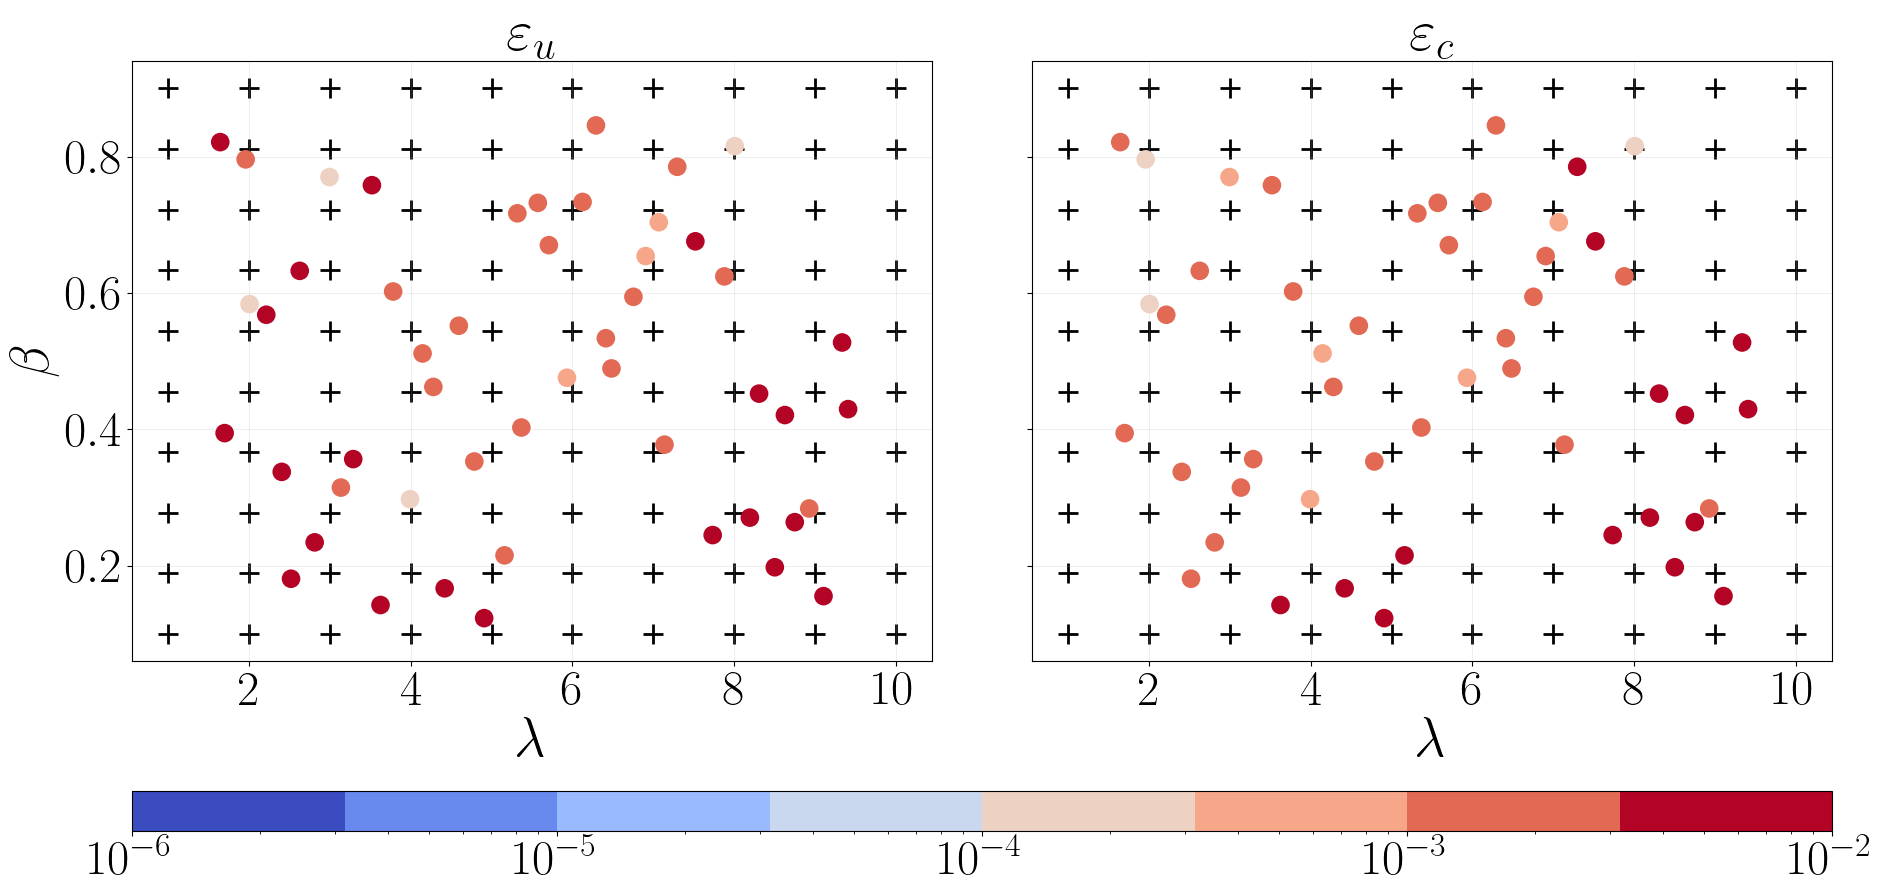

In [5]:
plot = Plot(fom, online, comp_indices=[])
plot.plot_relative_error()